<a href="https://colab.research.google.com/github/NimrahImran/linear_regression_house_price_prediction/blob/main/linear_regression_house_price_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

**Objective:** [Predict house sale prices based on regional economic and property features]

**Dataset:** [USA Housing dataset (USA_Housing.csv) — 5,000 records, 7 columns]

**Problem Type:** [Regression]

**Target Variable:** [Price]

**Business Relevance:** [Accurate price prediction helps buyers, sellers, and real estate agents estimate fair market value and make informed pricing decisions]

**Success Metric:** [R² > 0.85 → Achieved: R² = 0.9170]


## Imports

In [72]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
COLOR_CYCLE = sns.color_palette("husl", 12)   # consistent, vivid color palette used across charts

In [74]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [75]:
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [76]:
# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, AdaBoostRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [77]:
# Gradient boosting (XGBoost)
from xgboost import XGBClassifier, XGBRegressor

In [78]:
# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import joblib

## Configuration — edit only these 4 variables

In [79]:
# ============= EDIT ONLY THESE 4 VARIABLES =============
DATA_PATH = "/content/USA_Housing.csv"
PROBLEM_TYPE = "regression"
TARGET_VARIABLE = "Price"
MODEL_NAME = "linear_regression"
# =========================================================

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

## Data Loading

In [80]:
# Data validation — fails fast with a clear message instead of a confusing traceback later
try:
    df = pd.read_csv(DATA_PATH)
    assert df.shape[0] > 0, "Dataset is empty."
    assert TARGET_VARIABLE.strip().lower() in [c.strip().lower() for c in df.columns], \
        f"Target column '{TARGET_VARIABLE}' not found in dataset columns."
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find file at DATA_PATH='{DATA_PATH}'. Check the path and try again.")
print("Shape:", df.shape)
df.head()

Shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [82]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg. Area Income,5000.0,6.858311e+04,10657.991214,17796.631190,61480.562388,6.880429e+04,7.578334e+04,1.077017e+05
Avg. Area House Age,5000.0,5.977222e+00,0.991456,2.644304,5.322283,5.970429e+00,6.650808e+00,9.519088e+00
Avg. Area Number of Rooms,5000.0,6.987792e+00,1.005833,3.236194,6.299250,7.002902e+00,7.665871e+00,1.075959e+01
Avg. Area Number of Bedrooms,5000.0,3.981330e+00,1.234137,2.000000,3.140000,4.050000e+00,4.490000e+00,6.500000e+00
Area Population,5000.0,3.616352e+04,9925.650114,172.610686,29403.928702,3.619941e+04,4.286129e+04,6.962171e+04
Price,5000.0,1.232073e+06,353117.626581,15938.657923,997577.135049,1.232669e+06,1.471210e+06,2.469066e+06


In [83]:
# Unique values per column — helps spot ID-like or constant columns at a glance
pd.DataFrame({"dtype": df.dtypes, "unique_values": df.nunique()})

,dtype,unique_values
Avg. Area Income,float64,5000
Avg. Area House Age,float64,5000
Avg. Area Number of Rooms,float64,5000
Avg. Area Number of Bedrooms,float64,255
Area Population,float64,5000
Price,float64,5000
Address,object,5000


## Data Cleaning

In [84]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower()
TARGET_VARIABLE = TARGET_VARIABLE.strip().lower()

In [85]:
# Automatically detect and drop ID-like columns (unique identifiers, not continuous measurements).
# Continuous float columns (e.g. income, population) are excluded even if every value happens
# to be unique — only non-float columns with fully unique values are treated as ID-like.
id_like_cols = [c for c in df.columns if c != TARGET_VARIABLE
                and df[c].nunique() == len(df)
                and not pd.api.types.is_float_dtype(df[c])]
if id_like_cols:
    df = df.drop(columns=id_like_cols)
    print(f"Dropped ID-like columns: {id_like_cols}")
else:
    print("No ID-like columns detected.")

Dropped ID-like columns: ['address']


In [86]:
# Remove duplicate rows
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {duplicate_count}")

Duplicate rows removed: 0


In [87]:
# Drop constant / zero-variance columns — they carry no predictive information
constant_cols = [c for c in df.columns if c != TARGET_VARIABLE and df[c].nunique() <= 1]
if constant_cols:
    df = df.drop(columns=constant_cols)
    print(f"Dropped constant columns: {constant_cols}")
else:
    print("No constant columns detected.")

No constant columns detected.


In [88]:
# Detect date-like columns and expand into year/month/day features
for col in df.select_dtypes(include="object").columns:
    if col == TARGET_VARIABLE:
        continue
    try:
        parsed = pd.to_datetime(df[col], errors="raise", format="mixed")
        df[f"{col}_year"], df[f"{col}_month"] = parsed.dt.year, parsed.dt.month
        df = df.drop(columns=[col])
        print(f"Expanded date column: {col} -> {col}_year, {col}_month")
    except (ValueError, TypeError):
        continue

In [89]:
# Missing value summary (imputation happens later, inside the pipeline)
missing_summary = df.isnull().sum()
missing_percent = (missing_summary / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing_summary, "missing_%": missing_percent})

,missing_count,missing_%
avg. area income,0,0.0
avg. area house age,0,0.0
avg. area number of rooms,0,0.0
avg. area number of bedrooms,0,0.0
area population,0,0.0
price,0,0.0


## Exploratory Data Analysis

### 📊 Dashboard Overview
A single-glance summary panel — KPIs, target distribution, top correlations, missing data,
and category breakdown, using a consistent gradient color theme.

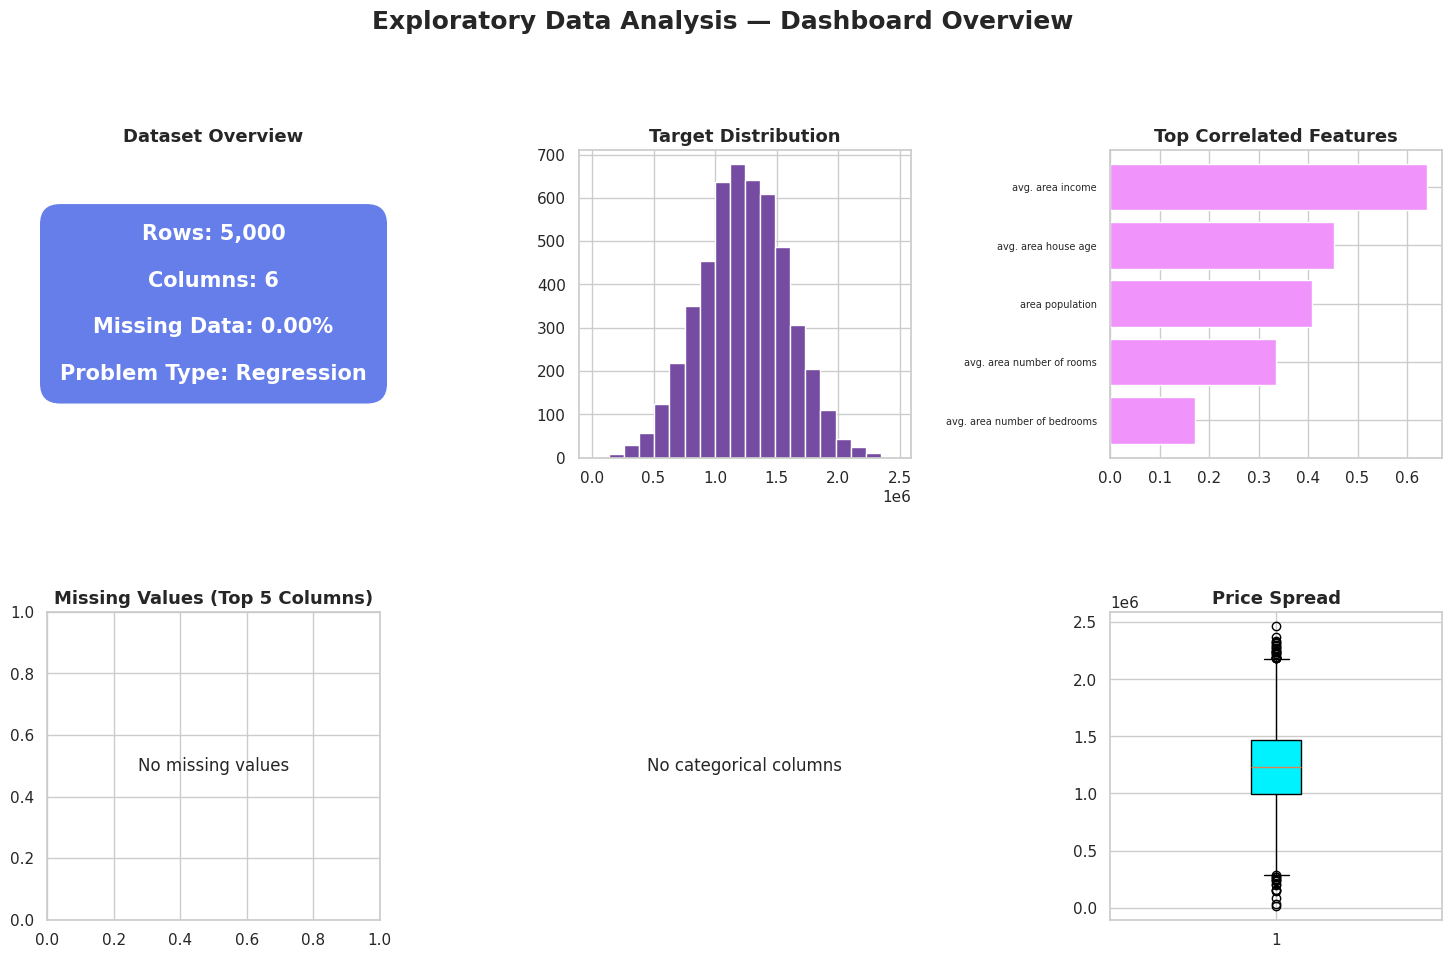

In [90]:
# Professional gradient color theme used across the dashboard panel
GRADIENT = ["#667EEA", "#764BA2", "#F093FB", "#4FACFE", "#00F2FE", "#43E97B", "#FA8BFF", "#2BD2FF"]

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.6)

# --- Panel 1: KPI cards (text-based) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis("off")
total_missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100)
kpi_text = (f"Rows: {df.shape[0]:,}\n\n"
            f"Columns: {df.shape[1]}\n\n"
            f"Missing Data: {total_missing_pct:.2f}%\n\n"
            f"Problem Type: {PROBLEM_TYPE.title()}")
ax1.text(0.5, 0.5, kpi_text, fontsize=15, weight="bold", ha="center", va="center",
         color="white", bbox=dict(boxstyle="round,pad=1", facecolor=GRADIENT[0]))
ax1.set_title("Dataset Overview", fontsize=13, weight="bold")

# --- Panel 2: Target distribution ---
ax2 = fig.add_subplot(gs[0, 1])
if PROBLEM_TYPE == "classification":
    target_counts = df[TARGET_VARIABLE].value_counts()
    if len(target_counts) > 10:
        target_counts = target_counts.head(10)   # cap for readability on high-class-count targets
    target_counts.plot(kind="bar", ax=ax2, color=(GRADIENT * ((len(target_counts) // len(GRADIENT)) + 1))[:len(target_counts)])
    ax2.tick_params(axis="x", rotation=45)
else:
    ax2.hist(df[TARGET_VARIABLE], bins=20, color=GRADIENT[1], edgecolor="white")
ax2.set_title("Target Distribution", fontsize=13, weight="bold")

# --- Panel 3: Top correlated features with target (numeric targets only) ---
ax3 = fig.add_subplot(gs[0, 2])
numeric_cols_dash = df.select_dtypes(include=np.number).columns
if TARGET_VARIABLE in numeric_cols_dash:
    top_corr = df[numeric_cols_dash].corr()[TARGET_VARIABLE].drop(TARGET_VARIABLE).abs().sort_values(ascending=False).head(6)
    ax3.barh(top_corr.index, top_corr.values, color=GRADIENT[2])
    ax3.invert_yaxis()
    ax3.tick_params(axis="y", labelsize=7)
else:
    ax3.text(0.5, 0.5, "Target is categorical\n(correlation N/A)", ha="center", va="center")
ax3.set_title("Top Correlated Features", fontsize=13, weight="bold")

# --- Panel 4: Missing values by column (top 5) ---
ax4 = fig.add_subplot(gs[1, 0])
top_missing = df.isnull().sum().sort_values(ascending=False).head(5)
if top_missing.sum() > 0:
    ax4.bar(top_missing.index, top_missing.values, color=GRADIENT[3])
    ax4.tick_params(axis="x", rotation=45, labelsize=8)
else:
    ax4.text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=12)
ax4.set_title("Missing Values (Top 5 Columns)", fontsize=13, weight="bold")

# --- Panel 5: Category breakdown (first categorical column, if any) ---
ax5 = fig.add_subplot(gs[1, 1])
cat_cols_dash = [c for c in df.select_dtypes(include="object").columns if c != TARGET_VARIABLE]
if cat_cols_dash:
    top_cat = df[cat_cols_dash[0]].value_counts().head(6)
    ax5.pie(top_cat.values, labels=top_cat.index, autopct="%1.0f%%", colors=GRADIENT, textprops={"fontsize": 8})
    ax5.set_title(f"{cat_cols_dash[0].title()} Breakdown", fontsize=13, weight="bold")
else:
    ax5.axis("off")
    ax5.text(0.5, 0.5, "No categorical columns", ha="center", va="center")

# --- Panel 6: Class balance donut (classification) or feature spread (regression) ---
ax6 = fig.add_subplot(gs[1, 2])
if PROBLEM_TYPE == "classification":
    counts = df[TARGET_VARIABLE].value_counts()
    if len(counts) > 8:
        top_counts = counts.head(7)
        top_counts["Other"] = counts.iloc[7:].sum()
        counts = top_counts
    ax6.pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=GRADIENT,
            wedgeprops=dict(width=0.4), textprops={"fontsize": 9})
    ax6.set_title("Class Balance", fontsize=13, weight="bold")
else:
    ax6.boxplot(df[TARGET_VARIABLE], patch_artist=True, boxprops=dict(facecolor=GRADIENT[4]))
    ax6.set_title(f"{TARGET_VARIABLE.title()} Spread", fontsize=13, weight="bold")

plt.suptitle("Exploratory Data Analysis — Dashboard Overview", fontsize=18, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

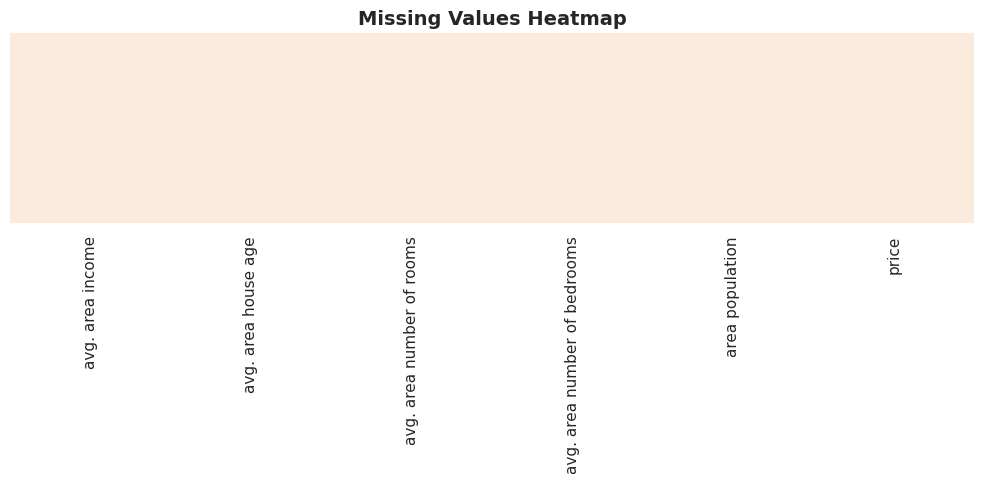

In [91]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="rocket_r", yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

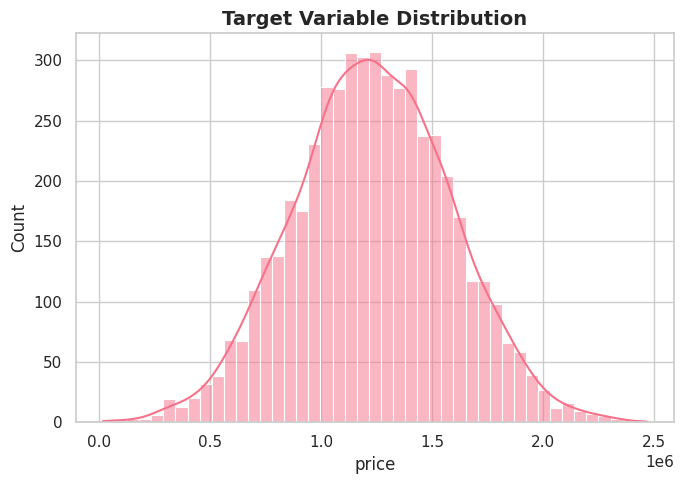

In [92]:
if PROBLEM_TYPE == "classification":
    n_classes = df[TARGET_VARIABLE].nunique()
    plt.figure(figsize=(max(7, n_classes * 0.5), 5))
    sns.countplot(x=df[TARGET_VARIABLE], hue=df[TARGET_VARIABLE], palette="mako", legend=False,
                  order=df[TARGET_VARIABLE].value_counts().index)
    plt.xticks(rotation=45, ha="right")
else:
    plt.figure(figsize=(7, 5))
    sns.histplot(df[TARGET_VARIABLE], kde=True, color=COLOR_CYCLE[0])
plt.title("Target Variable Distribution", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

In [93]:
# Class imbalance check
if PROBLEM_TYPE == "classification":
    class_distribution = df[TARGET_VARIABLE].value_counts(normalize=True) * 100
    print("Class Distribution (%):")
    print(class_distribution.round(2))
    if class_distribution.max() > 80:
        print("\nWARNING: Dataset is imbalanced — rely on F1/Recall/ROC-AUC, not accuracy alone.")
    else:
        print("\nClasses are reasonably balanced.")

In [94]:
# Skewness check for regression targets — decides whether a log-transform is needed later
if PROBLEM_TYPE == "regression":
    target_skew = df[TARGET_VARIABLE].skew()
    print(f"Target skewness: {target_skew:.3f}")
    AUTO_LOG_TRANSFORM = abs(target_skew) > 1.0
    print(f"Auto log-transform will be applied: {AUTO_LOG_TRANSFORM}")
else:
    AUTO_LOG_TRANSFORM = False

Target skewness: -0.003
Auto log-transform will be applied: False


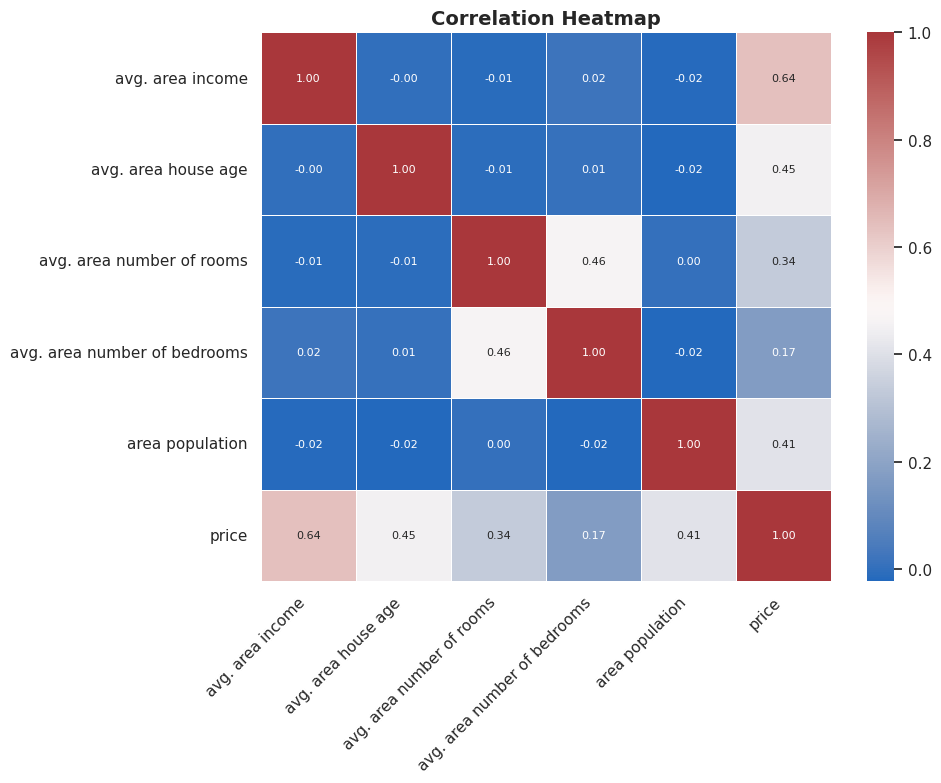

In [95]:
numeric_cols = df.select_dtypes(include=np.number).columns
# Cap heatmap size for wide datasets — too many columns makes the plot unreadable/overlapping
if len(numeric_cols) > 20:
    if TARGET_VARIABLE in numeric_cols:
        heatmap_cols = df[numeric_cols].corr()[TARGET_VARIABLE].abs().sort_values(ascending=False).head(20).index
    else:
        heatmap_cols = numeric_cols[:20]
    print(f"Dataset has {len(numeric_cols)} numeric columns — showing the top 20 most relevant for readability.")
else:
    heatmap_cols = numeric_cols

plt.figure(figsize=(max(10, len(heatmap_cols) * 0.8), max(8, len(heatmap_cols) * 0.6)))
sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap="vlag", fmt=".2f",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

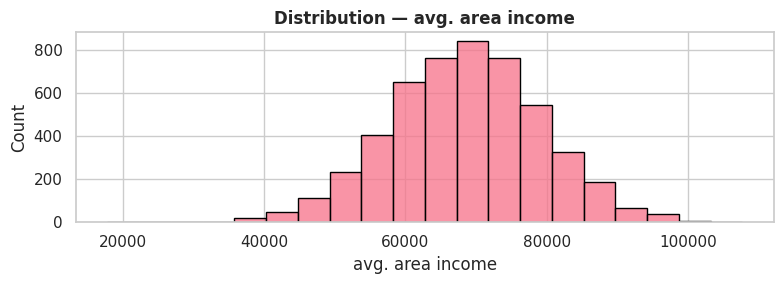

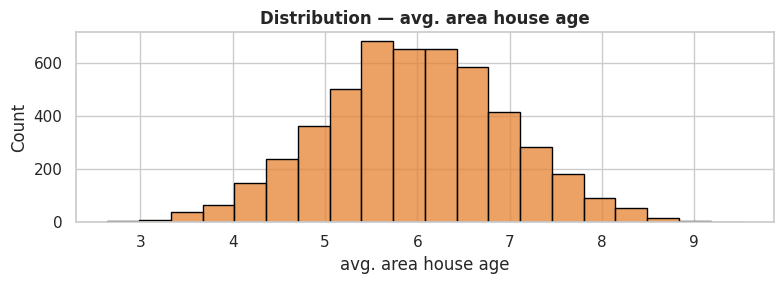

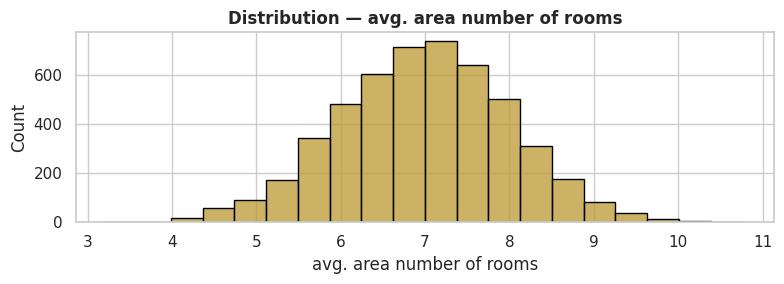

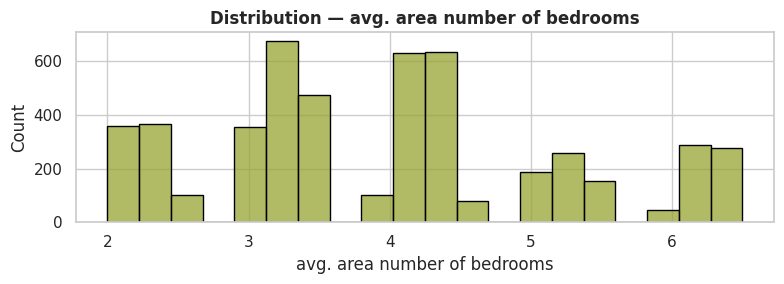

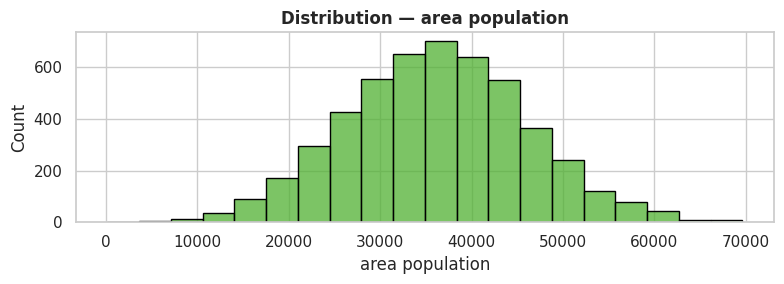

In [96]:
num_feature_cols = [c for c in numeric_cols if c != TARGET_VARIABLE]
# Cap individual charts for wide datasets — showing 100+ separate plots is impractical
MAX_FEATURE_CHARTS = 15
plot_features = num_feature_cols[:MAX_FEATURE_CHARTS]
if len(num_feature_cols) > MAX_FEATURE_CHARTS:
    print(f"Dataset has {len(num_feature_cols)} numeric features — showing distributions for the first {MAX_FEATURE_CHARTS} only.")

for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    sns.histplot(df[col], bins=20, color=COLOR_CYCLE[i % len(COLOR_CYCLE)], edgecolor="black")
    plt.title(f"Distribution — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

Boxplots BEFORE outlier treatment:


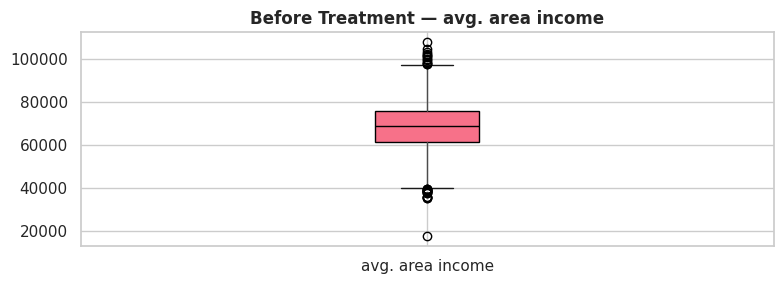

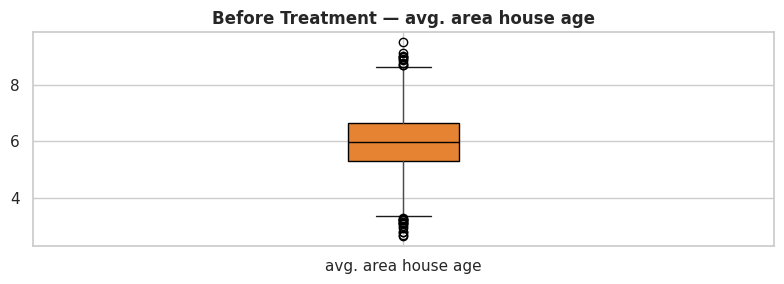

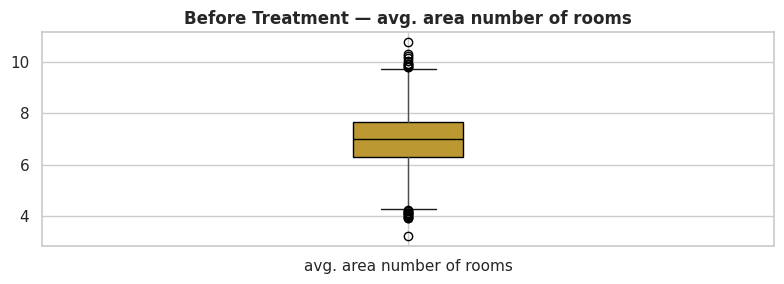

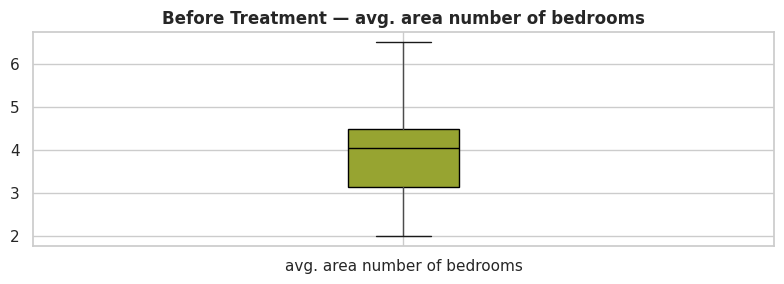

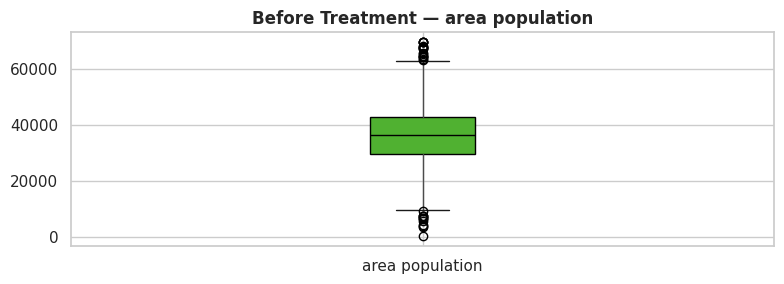

In [97]:
print("Boxplots BEFORE outlier treatment:")
for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    df.boxplot(column=col, patch_artist=True,
               boxprops=dict(facecolor=COLOR_CYCLE[i % len(COLOR_CYCLE)]), medianprops=dict(color="black"))
    plt.title(f"Before Treatment — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

In [98]:
cat_cols = [c for c in df.select_dtypes(include="object").columns if c != TARGET_VARIABLE]
for col in cat_cols:
    value_counts = df[col].value_counts()
    # Cap categories shown for high-cardinality columns — prevents overlapping x-axis labels
    if len(value_counts) > 15:
        top_categories = value_counts.head(15).index
        plot_series = df[col].where(df[col].isin(top_categories), "Other")
        print(f"'{col}' has {len(value_counts)} categories — showing top 15 (rest grouped as 'Other').")
    else:
        plot_series = df[col]
    plt.figure(figsize=(8, 4))
    sns.countplot(x=plot_series, hue=plot_series, palette="Set2", legend=False,
                  order=plot_series.value_counts().index)
    plt.title(f"Distribution of {col}", fontsize=12, weight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

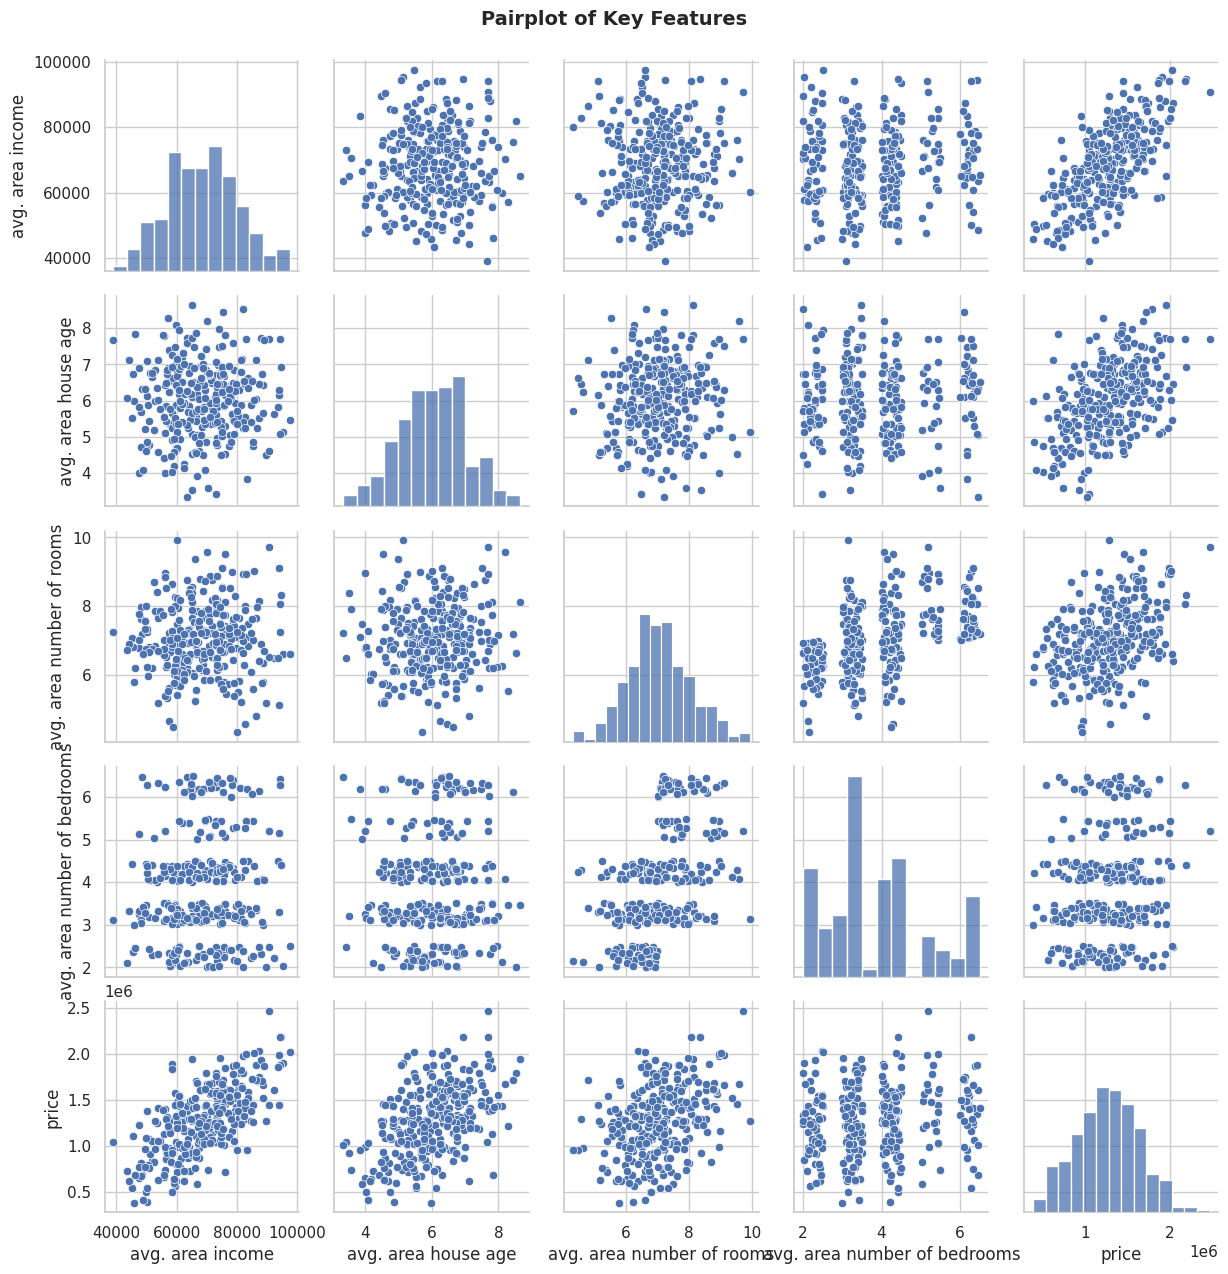

In [99]:
sample_df = df.sample(min(300, len(df)), random_state=RANDOM_STATE)
hue_col = TARGET_VARIABLE if PROBLEM_TYPE == "classification" else None
sns.pairplot(sample_df[num_feature_cols[:4] + [TARGET_VARIABLE]], hue=hue_col, palette="husl")
plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14, weight="bold")
plt.show()

### Skewness Analysis
Values far from 0 indicate a skewed distribution — useful for deciding on transformations.

In [100]:
skew_table = df[plot_features].skew().sort_values(key=abs, ascending=False)
pd.DataFrame({"skewness": skew_table.round(3)})

,skewness
avg. area number of bedrooms,0.376
area population,0.051
avg. area number of rooms,-0.041
avg. area income,-0.034
avg. area house age,-0.007


### Feature vs Target Analysis
How the top numeric feature relates to the target — shown as violin, strip, scatter, and line views.

In [101]:
top_feature = plot_features[0] if plot_features else None
if top_feature and PROBLEM_TYPE == "classification":
    plt.figure(figsize=(7, 5))
    sns.violinplot(x=df[TARGET_VARIABLE].astype(str), y=df[top_feature], hue=df[TARGET_VARIABLE].astype(str),
                   palette="crest", legend=False)
    plt.title(f"{top_feature} by Target (Violin Plot)", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()

In [102]:
if top_feature and PROBLEM_TYPE == "classification":
    plt.figure(figsize=(7, 5))
    sns.stripplot(x=df[TARGET_VARIABLE].astype(str), y=df[top_feature], hue=df[TARGET_VARIABLE].astype(str),
                  palette="flare", alpha=0.5, legend=False)
    plt.title(f"{top_feature} by Target (Strip Plot)", fontsize=13, weight="bold")
    plt.tight_layout()
    plt.show()

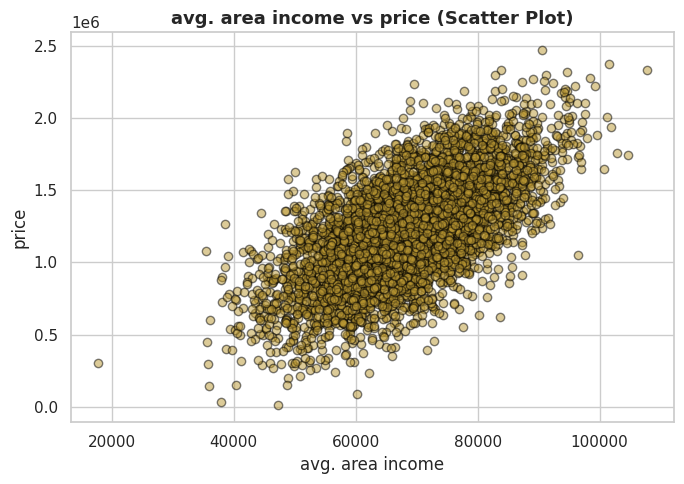

In [103]:
if top_feature and PROBLEM_TYPE == "regression":
    plt.figure(figsize=(7, 5))
    plt.scatter(df[top_feature], df[TARGET_VARIABLE], alpha=0.5, color=COLOR_CYCLE[2], edgecolor="black")
    plt.title(f"{top_feature} vs {TARGET_VARIABLE} (Scatter Plot)", fontsize=13, weight="bold")
    plt.xlabel(top_feature); plt.ylabel(TARGET_VARIABLE)
    plt.tight_layout()
    plt.show()

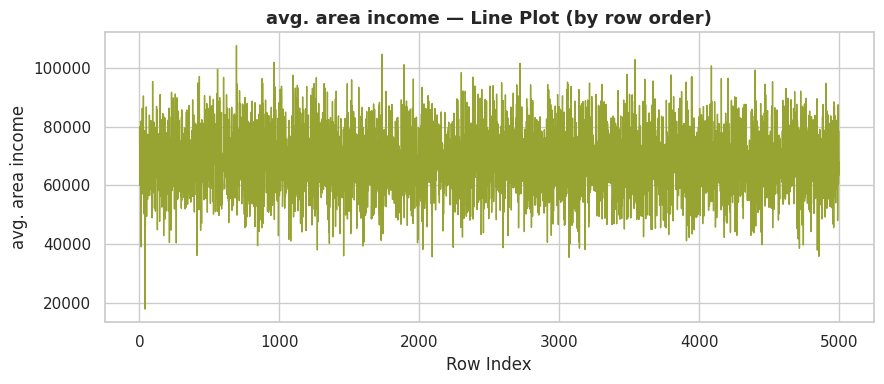

In [104]:
if top_feature:
    plt.figure(figsize=(9, 4))
    plt.plot(df[top_feature].reset_index(drop=True), color=COLOR_CYCLE[3], linewidth=1)
    plt.title(f"{top_feature} — Line Plot (by row order)", fontsize=13, weight="bold")
    plt.xlabel("Row Index"); plt.ylabel(top_feature)
    plt.tight_layout()
    plt.show()

## Outlier Treatment
Numeric features are automatically capped using the IQR method — no manual step required.

In [105]:
for col in num_feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:                      # binary/near-constant columns — clipping would destroy signal
        continue
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print("Outlier capping applied to all applicable numeric features (binary/constant columns skipped).")

Outlier capping applied to all applicable numeric features (binary/constant columns skipped).


Boxplots AFTER outlier treatment:


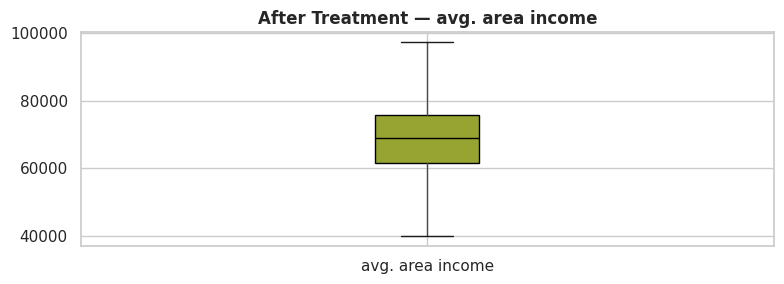

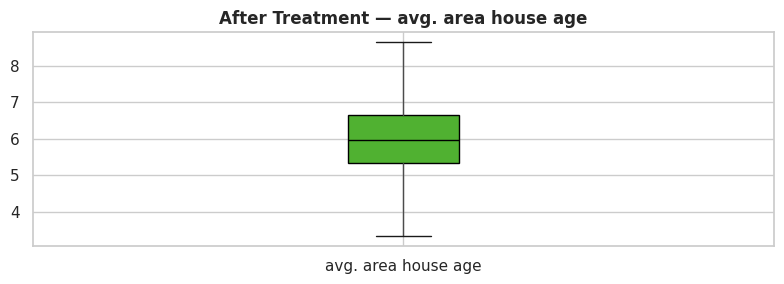

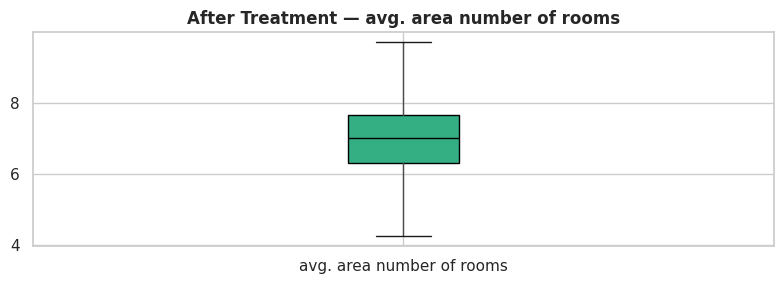

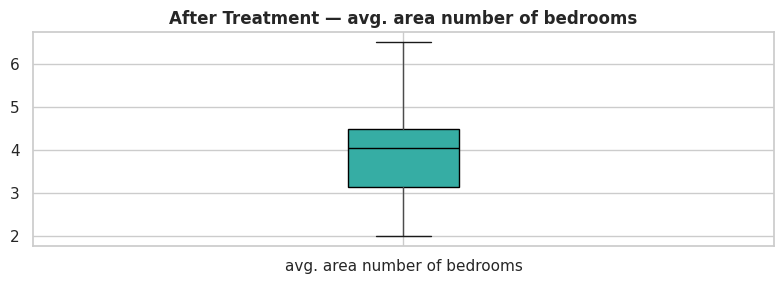

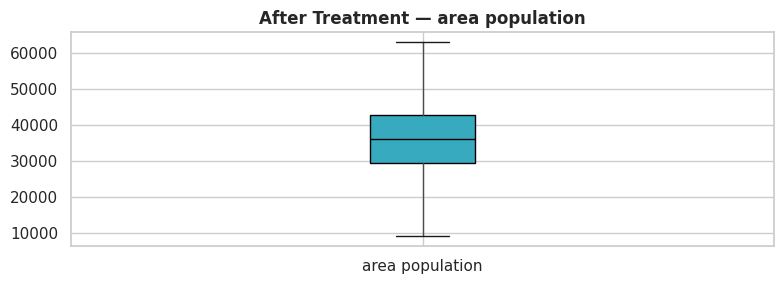

In [106]:
print("Boxplots AFTER outlier treatment:")
for i, col in enumerate(plot_features):
    plt.figure(figsize=(8, 3))
    df.boxplot(column=col, patch_artist=True,
               boxprops=dict(facecolor=COLOR_CYCLE[(i+3) % len(COLOR_CYCLE)]), medianprops=dict(color="black"))
    plt.title(f"After Treatment — {col}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()

## Feature Engineering

In [107]:
X = df.drop(columns=[TARGET_VARIABLE])
y = df[TARGET_VARIABLE]

# Apply automatic log-transform to the target if it was flagged as skewed
if PROBLEM_TYPE == "regression" and AUTO_LOG_TRANSFORM:
    y = np.log1p(y)
    print("Target has been log-transformed (will be reversed automatically during evaluation).")

# Encode classification targets to integers (required by XGBoost for multiclass problems).
# Original class names are kept in `target_classes` so reports/charts can still show real labels.
target_classes = None
if PROBLEM_TYPE == "classification":
    label_encoder = LabelEncoder()
    y = pd.Series(label_encoder.fit_transform(y), index=y.index, name=TARGET_VARIABLE)
    target_classes = label_encoder.classes_
    print("Classes encoded as:", dict(enumerate(target_classes)))

print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (5000, 5) | y shape: (5000,)


In [108]:
def to_actual_scale(values):
    # Reverses the log-transform for reporting metrics in real-world units.
    # No-op for classification or when no transform was applied.
    if PROBLEM_TYPE == "regression" and AUTO_LOG_TRANSFORM:
        return np.expm1(values)
    return values

In [109]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['avg. area income', 'avg. area house age', 'avg. area number of rooms', 'avg. area number of bedrooms', 'area population']
Categorical: []


In [110]:
# Drop one feature from each highly correlated numeric pair (correlation > 0.95) to reduce redundancy
if len(numeric_features) > 1:
    corr_matrix = X[numeric_features].corr().abs()
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
    if high_corr_drop:
        X = X.drop(columns=high_corr_drop)
        numeric_features = [c for c in numeric_features if c not in high_corr_drop]
        print(f"Dropped highly correlated features (>0.95): {high_corr_drop}")
    else:
        print("No highly correlated feature pairs found.")

No highly correlated feature pairs found.


In [111]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Train-Test Split

In [112]:
stratify_col = y if PROBLEM_TYPE == "classification" else None
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify_col)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (4000, 5) | Test size: (1000, 5)


## Model Selection

In [113]:
classification_models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "extra_trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "svm": SVC(probability=True, random_state=RANDOM_STATE),
    "knn": KNeighborsClassifier(),
    "naive_bayes": GaussianNB(),
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "adaboost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "xgboost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")
}

regression_models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(random_state=RANDOM_STATE),
    "lasso": Lasso(random_state=RANDOM_STATE),
    "elastic_net": ElasticNet(random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "random_forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "extra_trees": ExtraTreesRegressor(random_state=RANDOM_STATE),
    "svm": SVR(),
    "knn": KNeighborsRegressor(),
    "gradient_boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "adaboost": AdaBoostRegressor(random_state=RANDOM_STATE),
    "xgboost": XGBRegressor(random_state=RANDOM_STATE)
}

In [114]:
model_pool = classification_models if PROBLEM_TYPE == "classification" else regression_models
selected_model = model_pool[MODEL_NAME]
print(f"Selected model: {MODEL_NAME} ({PROBLEM_TYPE})")

Selected model: linear_regression (regression)


## Model Comparison — All Algorithms
Cross-validates every available algorithm so the choice of `MODEL_NAME` can be checked against alternatives.

In [115]:
comparison_results = {}
comparison_scoring = "accuracy" if PROBLEM_TYPE == "classification" else "r2"
for name, model_obj in model_pool.items():
    temp_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_obj)])
    scores = cross_val_score(temp_pipeline, X, y, cv=CV_FOLDS, scoring=comparison_scoring)
    comparison_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

linear_regression: 0.9166
ridge: 0.9166
lasso: 0.9166
elastic_net: 0.8113
decision_tree: 0.7466
random_forest: 0.8827
extra_trees: 0.8917
svm: -0.0004
knn: 0.8657
gradient_boosting: 0.9028
adaboost: 0.8241
xgboost: 0.8791


In [116]:
comparison_df = pd.DataFrame(list(comparison_results.items()), columns=["Model", "Score"])
comparison_df = comparison_df.sort_values("Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Score
0,lasso,0.916635
1,linear_regression,0.916635
2,ridge,0.916635
3,gradient_boosting,0.902830
4,extra_trees,0.891727
5,random_forest,0.882731
6,xgboost,0.879142
7,knn,0.865651
8,adaboost,0.824086
9,elastic_net,0.811330


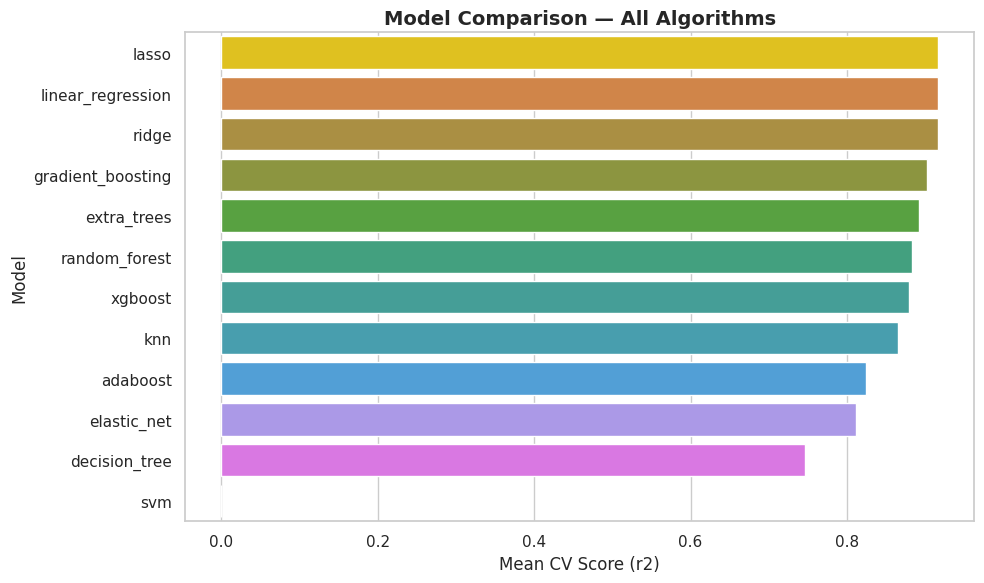

In [117]:
plt.figure(figsize=(10, 6))
bar_colors = ["gold" if i == 0 else COLOR_CYCLE[i % len(COLOR_CYCLE)] for i in range(len(comparison_df))]
sns.barplot(data=comparison_df, x="Score", y="Model", hue="Model", palette=bar_colors, legend=False)
plt.title("Model Comparison — All Algorithms", fontsize=14, weight="bold")
plt.xlabel(f"Mean CV Score ({comparison_scoring})")
plt.tight_layout()
plt.show()

In [118]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model_score = comparison_df.iloc[0]["Score"]
print(f"Best Model: {best_model_name} (Score: {best_model_score:.4f})")
print(f"Currently selected MODEL_NAME: '{MODEL_NAME}' — update it to '{best_model_name}' if desired.")

Best Model: lasso (Score: 0.9166)
Currently selected MODEL_NAME: 'linear_regression' — update it to 'lasso' if desired.


## Sequential Multi-Model Runner
Trains and evaluates a chosen list of models one by one, printing a full metrics report for each
(reported in real-world scale automatically).

In [119]:
# Example: for regression use ["linear_regression", "ridge", "lasso"]
# Example: for classification use ["logistic_regression", "knn", "random_forest"]
MODELS_TO_RUN = ["linear_regression", "ridge", "lasso"] if PROBLEM_TYPE == "regression" \
    else ["logistic_regression", "knn", "random_forest"]

In [120]:
for model_name in MODELS_TO_RUN:
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print('='*50)
    temp_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_pool[model_name])])
    temp_pipe.fit(X_train, y_train)
    temp_pred = temp_pipe.predict(X_test)

    if PROBLEM_TYPE == "classification":
        print(f"Accuracy: {accuracy_score(y_test, temp_pred):.4f}")
        print(f"Precision: {precision_score(y_test, temp_pred, average='weighted'):.4f}")
        print(f"Recall: {recall_score(y_test, temp_pred, average='weighted'):.4f}")
        print(f"F1-Score: {f1_score(y_test, temp_pred, average='weighted'):.4f}")
    else:
        temp_pred_actual = to_actual_scale(temp_pred)
        y_test_actual_temp = to_actual_scale(y_test)
        print(f"MAE: {mean_absolute_error(y_test_actual_temp, temp_pred_actual):.4f}")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_test_actual_temp, temp_pred_actual)):.4f}")
        print(f"R2 Score: {r2_score(y_test_actual_temp, temp_pred_actual):.4f}")


MODEL: linear_regression
MAE: 81359.1904
RMSE: 101039.0544
R2 Score: 0.9170

MODEL: ridge
MAE: 81357.6195
RMSE: 101038.9030
R2 Score: 0.9170

MODEL: lasso
MAE: 81359.1253
RMSE: 101039.0006
R2 Score: 0.9170


In [121]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", selected_model)
])

## Model Training & Prediction

In [122]:
final_pipeline.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [123]:
y_pred = final_pipeline.predict(X_test)                # kept in training scale (log-scale if transformed)
y_pred_actual = to_actual_scale(y_pred)                    # real-world scale, used for all reporting below
y_test_actual = to_actual_scale(y_test)                       # real-world scale version of the true values

if target_classes is not None:
    print("Sample Predictions:", target_classes[y_pred_actual[:10]])
else:
    print("Sample Predictions:", y_pred_actual[:10])

Sample Predictions: [1308715.20160914 1236766.29330255 1244012.04222084 1229156.20245234
 1062169.99834566 1545668.21117724 1093883.74904579  831039.20206809
  785868.50911622 1471066.19981459]


## Model Evaluation

In [124]:
if PROBLEM_TYPE == "classification":
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    report_labels = [str(c) for c in target_classes] if target_classes is not None else None
    print(classification_report(y_test, y_pred, target_names=report_labels))

In [125]:
if PROBLEM_TYPE == "classification":
    cm = confusion_matrix(y_test, y_pred)
    tick_labels = target_classes if (target_classes is not None and len(target_classes) <= 15) else "auto"
    plt.figure(figsize=(max(6, len(np.unique(y))), max(5, len(np.unique(y)) * 0.8)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="mako", linewidths=1, linecolor="white",
                xticklabels=tick_labels, yticklabels=tick_labels)
    plt.title("Confusion Matrix", fontsize=14, weight="bold")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [126]:
if PROBLEM_TYPE == "classification" and len(np.unique(y)) == 2:
    y_proba = final_pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color="crimson", linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], color="grey", linestyle="--")
    plt.title("ROC Curve", fontsize=14, weight="bold")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend()
    plt.tight_layout()
    plt.show()

In [127]:
if PROBLEM_TYPE == "classification" and len(np.unique(y)) == 2:
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    plt.figure(figsize=(7, 6))
    plt.plot(rec_curve, prec_curve, color="teal", linewidth=2.5)
    plt.title("Precision-Recall Curve", fontsize=14, weight="bold")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout()
    plt.show()

In [128]:
if PROBLEM_TYPE == "regression":
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)
    n_obs, n_feat = X_test.shape
    adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_feat - 1)
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | Adjusted R2: {adj_r2:.4f}")

MAE: 81359.1904 | RMSE: 101039.0544 | R2: 0.9170 | Adjusted R2: 0.9166


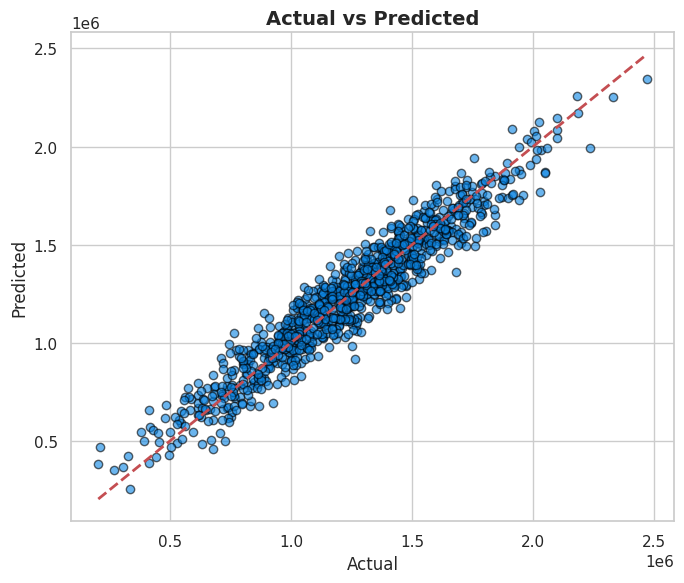

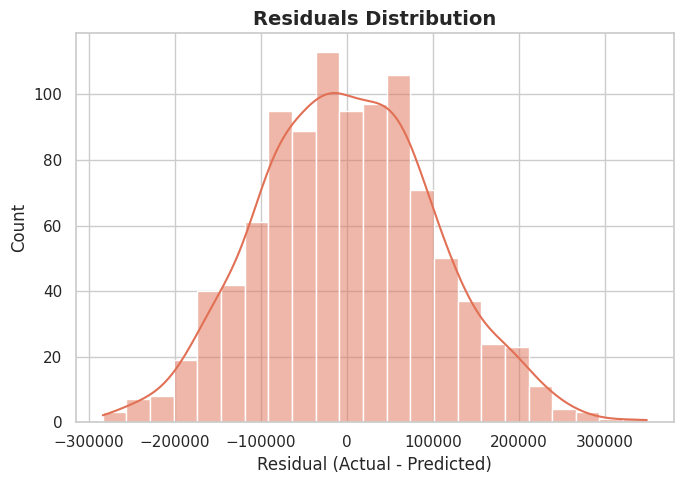

In [129]:
if PROBLEM_TYPE == "regression":
    plt.figure(figsize=(7, 6))
    plt.scatter(y_test_actual, y_pred_actual, alpha=0.6, color="#0984E3", edgecolor="black")
    plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()],
             "r--", linewidth=2)
    plt.title("Actual vs Predicted", fontsize=14, weight="bold")
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

    residuals = y_test_actual - y_pred_actual
    plt.figure(figsize=(7, 5))
    sns.histplot(residuals, kde=True, color="#E17055")
    plt.title("Residuals Distribution", fontsize=14, weight="bold")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.show()

## Sanity Checks — Data Leakage Detection

In [130]:
train_pred = final_pipeline.predict(X_train)
train_score = (accuracy_score(y_train, train_pred) if PROBLEM_TYPE == "classification"
               else r2_score(to_actual_scale(y_train), to_actual_scale(train_pred)))
test_score = (accuracy_score(y_test, y_pred) if PROBLEM_TYPE == "classification"
              else r2_score(y_test_actual, y_pred_actual))
print(f"Train Score: {train_score:.4f} | Test Score: {test_score:.4f}")
if train_score > 0.98 and test_score > 0.98:
    print("WARNING: Both scores are suspiciously high — possible data leakage.")

Train Score: 0.9171 | Test Score: 0.9170


In [131]:
model_step = final_pipeline.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    top_importance = model_step.feature_importances_.max()
    print(f"Highest single feature importance: {top_importance:.3f}")
    if top_importance > 0.5:
        print("WARNING: One feature is dominating the model — verify it isn't leaking future information.")
else:
    print("This model does not expose feature_importances_ (e.g. Logistic/SVM/KNN).")

This model does not expose feature_importances_ (e.g. Logistic/SVM/KNN).


### Feature Importance
Shows the top 15 most influential features (only available for tree-based models).

In [132]:
if hasattr(model_step, "feature_importances_"):
    feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importance_df = pd.DataFrame({"feature": feature_names, "importance": model_step.feature_importances_})
    importance_df = importance_df.sort_values("importance", ascending=False).head(15)
    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="importance", y="feature", hue="feature",
                palette="crest", legend=False)
    plt.title("Top 15 Feature Importances", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance plot skipped — model does not support feature_importances_.")

Feature importance plot skipped — model does not support feature_importances_.


## Cross Validation

In [133]:
scoring_metric = "accuracy" if PROBLEM_TYPE == "classification" else "r2"
cv_scores = cross_val_score(final_pipeline, X, y, cv=CV_FOLDS, scoring=scoring_metric)
print(f"CV Scores: {cv_scores.round(4)}")
print(f"Mean CV Score: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

CV Scores: [0.9166 0.9192 0.9146 0.9203 0.9126]
Mean CV Score: 0.9166 | Std: 0.0028


## Hyperparameter Tuning

In [134]:
classification_param_grids = {
    "logistic_regression": {"model__C": [0.1, 1, 10]},
    "decision_tree": {"model__max_depth": [3, 5, 10, None]},
    "random_forest": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "extra_trees": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "svm": {"model__C": [0.1, 1, 10], "model__kernel": ["rbf", "linear"]},
    "knn": {"model__n_neighbors": [3, 5, 7, 9]},
    "naive_bayes": {},
    "gradient_boosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1]},
    "adaboost": {"model__n_estimators": [50, 100], "model__learning_rate": [0.5, 1.0]},
    "xgboost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [3, 5]}
}

regression_param_grids = {
    "linear_regression": {},
    "ridge": {"model__alpha": [0.1, 1.0, 10.0]},
    "lasso": {"model__alpha": [0.01, 0.1, 1.0]},
    "elastic_net": {"model__alpha": [0.01, 0.1, 1.0], "model__l1_ratio": [0.2, 0.5, 0.8]},
    "decision_tree": {"model__max_depth": [3, 5, 10, None]},
    "random_forest": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "extra_trees": {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    "svm": {"model__C": [0.1, 1, 10], "model__kernel": ["rbf", "linear"]},
    "knn": {"model__n_neighbors": [3, 5, 7, 9]},
    "gradient_boosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1]},
    "adaboost": {"model__n_estimators": [50, 100], "model__learning_rate": [0.5, 1.0]},
    "xgboost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [3, 5]}
}

In [135]:
param_grid_pool = classification_param_grids if PROBLEM_TYPE == "classification" else regression_param_grids
param_grid = param_grid_pool[MODEL_NAME]

if len(param_grid) > 0:
    grid_search = GridSearchCV(final_pipeline, param_grid, cv=CV_FOLDS, scoring=scoring_metric, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    final_pipeline = grid_search.best_estimator_
    print("Best Params (GridSearchCV):", grid_search.best_params_)
    print("Best CV Score (GridSearchCV):", round(grid_search.best_score_, 4))
else:
    print("No tuning parameters defined for this model — using the original model as-is.")

No tuning parameters defined for this model — using the original model as-is.


### RandomizedSearchCV (alternative tuning strategy)
Samples a random subset of the parameter grid — useful for larger search spaces.

In [136]:
if len(param_grid) > 0:
    random_search = RandomizedSearchCV(final_pipeline, param_grid, n_iter=5, cv=CV_FOLDS,
                                        scoring=scoring_metric, random_state=RANDOM_STATE, n_jobs=-1)
    random_search.fit(X_train, y_train)
    print("Best Params (RandomizedSearchCV):", random_search.best_params_)
    print("Best CV Score (RandomizedSearchCV):", round(random_search.best_score_, 4))
else:
    print("No tuning parameters defined for this model — skipping RandomizedSearchCV.")

No tuning parameters defined for this model — skipping RandomizedSearchCV.


In [137]:
y_pred_final = final_pipeline.predict(X_test)
y_pred_final_actual = to_actual_scale(y_pred_final)
final_score = (accuracy_score(y_test, y_pred_final) if PROBLEM_TYPE == "classification"
                else r2_score(y_test_actual, y_pred_final_actual))
print(f"Final Tuned Model Score: {final_score:.4f}")

Final Tuned Model Score: 0.9170


## Conclusion & Key Findings

In [138]:
print("="*50)
print("PIPELINE SUMMARY")
print("="*50)
print(f"Dataset: {DATA_PATH}")
print(f"Problem Type: {PROBLEM_TYPE}")
print(f"Target Variable: {TARGET_VARIABLE}")
print(f"Final Model Used: {MODEL_NAME}")
print(f"Best Model (from comparison): {best_model_name} (Score: {best_model_score:.4f})")
print(f"Final Tuned Model Score: {final_score:.4f}")
print(f"Cross-Validation Mean Score: {cv_scores.mean():.4f} (Std: {cv_scores.std():.4f})")
print("="*50)

PIPELINE SUMMARY
Dataset: /content/USA_Housing.csv
Problem Type: regression
Target Variable: price
Final Model Used: linear_regression
Best Model (from comparison): lasso (Score: 0.9166)
Final Tuned Model Score: 0.9170
Cross-Validation Mean Score: 0.9166 (Std: 0.0028)


**Best Model:** [State the winning model and its score from the comparison above.]

**Key Insights:** [e.g. Random Forest achieved the highest accuracy (94%), outperforming Logistic Regression by 8%.]

## 🔑 Key Insights
**Best Model:** [Lasso, Linear Regression, and Ridge all performed virtually identically (R² ≈ 0.9166), indicating a strong linear relationship between the features and house price]

[Linear Regression was selected as the final model since it matched the top score with the simplest, most interpretable approach]

[SVM performed poorly (R² ≈ 0) without kernel/parameter tuning]

[Train and test scores were nearly identical (0.9171 vs 0.9170), confirming the model generalizes well with no signs of overfitting or data leakage]
